# 1.4 Coupled Acoustic, Elastic, And Poroelastic Layers

Coupled models combine material domains with different physics in one layered model. This tutorial uses an acoustic water layer, an elastic sediment layer, and a poroelastic basement layer. The top-level simulation physics is `coupled_aep`; individual layer physics tells the exporter how each layer's property dictionary should be interpreted.

The important design rule is simple: layer physics narrows the meaning of the properties on that layer. Acoustic layers use acoustic properties, elastic layers use elastic properties, and poroelastic layers use the elastic-frame plus Biot properties. Properties that are not supported by the selected layer physics should not be used to infer a different physics family.


## Imports


In [1]:

import matplotlib.pyplot as plt
import numpy as np
import frequensolve as fs

u = fs.ureg


## What This Adds To Single-Physics Models

The previous notebooks used one physics family for every layer. This notebook shows one simulation whose layers use different material families: acoustic water, elastic sediment, and poroelastic basement. The ordering of surfaces still defines layer intervals; `physics=` on each layer defines how that layer's properties are interpreted.

By the end, you should be able to read a mixed-domain model, place receivers that ask for fields meaningful in each domain, and use ParaView output to confirm that material labels and fields cross interfaces as expected.


## Mixed-Physics Material Properties

Coupled models use the same model-building API, but each material domain may declare its own physics. The layer physics determines which properties are active in that domain: acoustic layers use acoustic properties, elastic layers use elastic properties, and poroelastic layers use the elastic-frame plus Biot properties. Unsupported properties on a layer are ignored by the selected physics and should not be used to imply a different material family.

| Layer | Physics | Key properties | Role in the example |
| --- | --- | --- | --- |
| `water` | `acoustic` | `Vp`, `Rho`, optional `Qp` | Pressure-like acoustic propagation above the seafloor. |
| `elastic_sediment` | `elastic` | `Vp`, `Vs`, `Rho`, optional `Qp`/`Qs` | Adds shear support and elastic mode conversion. |
| `poroelastic_basement` | `poroelastic:iso` | Elastic-frame properties plus Biot solid/fluid/transport properties | Adds pore-pressure and relative-fluid response. |

The concrete property values below are deliberately simple and layer-constant. The point of this tutorial is the mixed-domain structure, not a geologically detailed velocity model.


## Layered Model With Domain Physics

The next cell creates one ordered layered model with three material intervals. Interfaces are still derived from the surface/layer sequence; the extra coupled behavior comes from `physics=` on the simulation and on each layer. This is the most explicit style for release-facing examples because users can see which domain owns which material vocabulary.


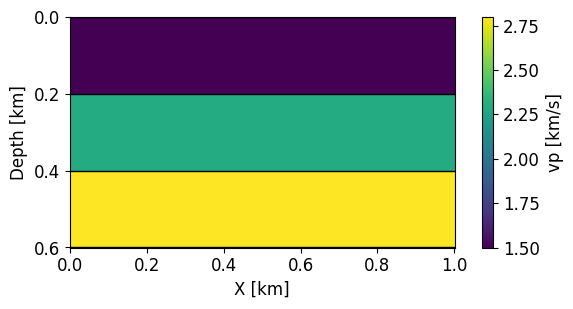

In [2]:
project = fs.Project(
    name="project",
    pretty_name="coupled_aep_basic",
    path="./scratch/tutorials/coupled_aep_basic",
    log_level="INFO",
    log_to_console=True,
)

sim = project.new_simulation(
    name="coupled_aep_basic",
    physics="coupled_aep",
    dimension=2,
    units={
        "length": "km",
        "velocity": "km/s",
        "density": "g/cm^3",
    },
)

model = fs.LayeredModel(dimension=2, x_limits=[0.0, 1.0])
model.add_surface(name="top", depth=0.0 * u.km)
model.add_layer(
    name="water",
    physics="acoustic",
    properties={"Vp": 1.5, "Rho": 1.0, "Qp": 100.0},
)
model.add_surface(name="seafloor", depth=0.2 * u.km)
model.add_layer(
    name="elastic_sediment",
    physics="elastic",
    properties={"Vp": 2.3, "Vs": 1.1, "Rho": 2.1, "Qp": 20.0, "Qs": 10.0},
)
model.add_surface(name="poro_interface", depth=0.4 * u.km)
model.add_layer(
    name="poroelastic_basement",
    physics="poroelastic:iso",
    properties={
        "Vp": 2.8 * u.km / u.s,
        "Qp": 20.0,
        "Vs": 1.5 * u.km / u.s,
        "Qs": 10.0,
        "Rho": 2.4 * u.g / u.cm**3,
        "k_solid": 18.0 * u.GPa,
        "k_fluid":  2.2 * u.GPa,
        "rho_solid": 2.70 * u.g / u.cm**3,
        "rho_fluid": 1.0 * u.g / u.cm**3,
        "porosity": 0.18,
        "tortuosity": 2.2,
        "kappa": 2.0e-10 * u.m**2,
        "viscosity": 1.0e-3 * u.Pa * u.s,
    },
)
model.add_surface(name="bottom", depth=0.6 * u.km)
sim += model
model.plot("vp", figsize=(7, 3), aspect="equal")


## Mesh And PML Across Domains

The same generated mesh spans all layers, and interfaces come from the ordered model surfaces. The top boundary is in the acoustic layer, so this notebook uses a free top boundary and PML on the side and bottom truncation boundaries. Poroelastic fluid boundary conditions such as `sealed` or `drained` are only meaningful on boundaries that actually touch poroelastic material.

PML is auto-extruded outside the selected exterior boundaries; it is not a fourth layer in the model. `pml_wavelengths=0.75` specifies the absorbing width in wavelengths, so the physical thickness is frequency-dependent and follows the solve frequency/local wave speed. The default `pml_reflection` is `1e-3`, which is a moderate target for introductory examples.


## Boundary Conditions Across Domains

| Boundary condition |Variables/components constrained | Typical use in this coupled model |
| --- | --- | --- |
| `free` | Natural acoustic/free mechanical trace depending on the material touching the boundary. | Top truncation boundary in the acoustic layer. |
| `pml` | Absorbing-layer equations for all active fields in the extruded PML region. | Side and bottom truncation boundaries. |
| `sealed` | Poroelastic normal relative fluid-flux trace `q_hat = 0`. | Poroelastic exterior boundaries, if present. |
| `drained` | Poroelastic pore-pressure trace `p_hat = 0`. | Poroelastic exterior boundaries where pore pressure is released. |


In [ ]:
sim += model.hex_mesh_generator([8, 4])
sim.mesh.set_adapt(elems_per_wave=2.0, order=4, f_low=5.0, f_high=30.0)
sim.mesh.set_source_grading(d1=0.08, mult=2.0)

sim += fs.BoundaryCondition(
    conditions=["free"],
    boundaries=["z_min"],
)
sim += fs.BoundaryCondition(
    conditions=["pml"],
    boundaries=["x_min", "x_max", "z_max"],
    pml_wavelengths=0.75,
)


## Receiver Fields In Coupled Models

A coupled survey usually records different observables in different domains. This notebook places hydrophones in the acoustic layer, geophones in the elastic layer, and pore-pressure receivers in the poroelastic layer. The source is in the acoustic layer, so the run exercises transmission through the acoustic-elastic and elastic-poroelastic interfaces.


In [ ]:
acq = fs.Acquisition()
acq.add_source_group(kind="scalar", coords=[[0.5, 0.025]])

hydrophone = fs.ReceiverNode(name="hydrophone")
hydrophone.add_component(name="p", field="pressure")
water_line = [[x, 0.05] for x in np.linspace(0.0, 1.0, 201)]
acq.add_receiver_group(name="water_line", device=hydrophone, coords=water_line)

geophone = fs.ReceiverNode(name="geophone")
geophone.add_component(name="v_z", field="velocity", direction=[0.0, 1.0])
sediment_line = [[x, 0.25] for x in np.linspace(0.0, 1.0, 201)]
acq.add_receiver_group(name="sediment_line", device=geophone, coords=sediment_line)

poro_node = fs.ReceiverNode(name="poro_pressure_node")
poro_node.add_component(name="pore_pressure", field="pressure")
poro_line = [[x, 0.45] for x in np.linspace(0.0, 1.0, 201)]
acq.add_receiver_group(name="poro_line", device=poro_node, coords=poro_line)

sim += acq


## Run The Coupled Job

The run cell is strict. Python-side setup errors should be fixed in the notebook, while solver-side coupled AEP failures should remain visible with their job logs. The next section runs a separate single-frequency QC job for ParaView output.


In [5]:
sim += fs.Discretization()
sim += fs.SolverConfig(tolerance=1.0e-4, grids=3)

site = fs.LocalSite(shutdown_on_completion=True, verbose=True)
job = fs.TimeDomainJob(
    name="time_coupled_aep",
    simulation=sim,
    f_min=0.0,
    f_max=45.0,
    T_max=2.0,
)
result = site.submit(job).wait()
traces = result.traces(upscale=4)
traces.summary


2026-05-14 03:01:34,298 [INFO] frequensolve.orchestrator.sites.local:716 - Initializing Dask with 16 workers, 1 threads per worker, 7372MB memory per worker
2026-05-14 03:01:36,425 [INFO] frequensolve.orchestrator.sites.local:802 - Dask dashboard available at http://localhost:60057/status
2026-05-14 03:01:36,678 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:time_coupled_aep: running


LocalSite local:time_coupled_aep: running


Running: time_coupled_aep 0/90 |          | Elapsed time: 00:00s

2026-05-14 03:02:17,123 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:time_coupled_aep: completed


LocalSite local:time_coupled_aep: completed


water_line
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['p']
  Frequencies	: 0.50 - 45.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s

sediment_line
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['v_z']
  Frequencies	: 0.50 - 45.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s

poro_line
  Receivers	: 1 - 201
  Shot		: 1
  Components	: ['pore_pressure']
  Frequencies	: 0.50 - 45.00 Hz (Δf=0.50)
  Window	: 0.00 - 2.00 s

## Inspect Traces By Domain

Use `traces.summary` to verify which groups and components were written, then select the receiver group and component expected for each material domain. The panels below use the same wavelet and display scale so differences in arrival character and amplitude are easy to inspect.


Text(0.5, 1.0, 'Center receiver response by domain')

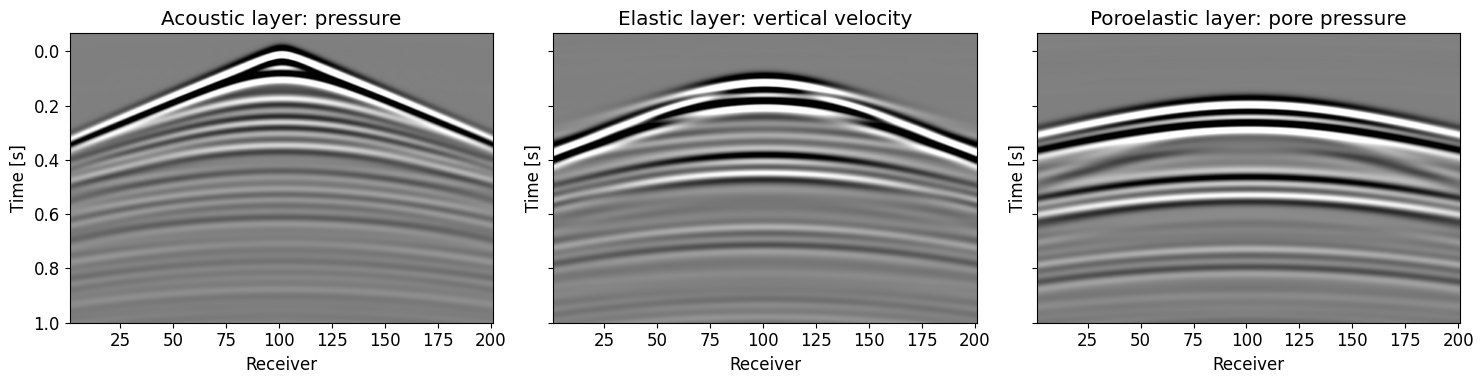

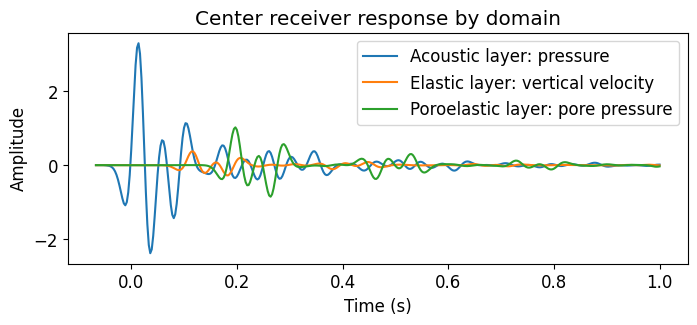

In [6]:
wavelet = fs.RickerWavelet(f=15.0)
selections = [
    ("water_line", "p", "Acoustic layer: pressure"),
    ("sediment_line", "v_z", "Elastic layer: vertical velocity"),
    ("poro_line", "pore_pressure", "Poroelastic layer: pore pressure"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
gathers = {}
for ax, (group, component, title) in zip(axes, selections):
    source = traces.sources(group)[0]
    gather = traces.td(group, component, source, wavelet, upscale=4, T_max=1.0)
    gathers[group] = gather
    fs.plot_gather(
        gather,
        ax=ax,
        A=2.0 * np.nanstd(np.real(gather.values)),
        cmap="gray",
        title=title,
    )
fig.tight_layout()

fig, ax = plt.subplots(figsize=(8, 3))
for group, component, label in selections:
    trace = gathers[group].isel(receiver=len(gathers[group].receiver) // 2)
    ax.plot(trace["time"].values, np.real(trace.values), label=label)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude")
ax.legend()
ax.set_title("Center receiver response by domain")


## Single-Frequency ParaView QC

Use a frequency-domain job when requesting VTK/ParaView files. This QC result writes pressure, velocity, and common material properties so the acoustic, elastic, and poroelastic domains can be inspected spatially after the trace comparison. The output is separate from the time-domain trace job because ParaView wavefields are tied to a specific frequency.

`upscale=0` keeps this coupled-domain QC output close to the native mesh. That makes subdomain labels, interfaces, and PML cells easier to diagnose before requesting larger smoothed field exports.


In [7]:
site_fd = fs.LocalSite(shutdown_on_completion=True, verbose=True)
fd_job = fs.FrequencyDomainJob(
    name="freq_coupled_aep_qc",
    simulation=sim,
    f_list=[15.0],
    outputs=[
        fs.ParaviewOutput(
            name="pv_coupled_aep",
            path="paraview",
            fields=["pressure", "velocity"],
            properties=["vp", "vs", "rho", "porosity", "Subdomain"],
            sources=[1],
            show_pml=True,
            upscale=0,
            order=1,
        )
    ],
)
fd_result = site_fd.submit(fd_job).wait()
fd_result.output_files(base="pv_coupled_aep", suffix=".vtu", existing=True)


2026-05-14 03:02:17,944 [INFO] frequensolve.orchestrator.sites.local:716 - Initializing Dask with 1 workers, 16 threads per worker, 117964MB memory per worker
2026-05-14 03:02:18,960 [INFO] frequensolve.orchestrator.sites.local:802 - Dask dashboard available at http://localhost:60213/status
2026-05-14 03:02:19,167 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:freq_coupled_aep_qc: running


LocalSite local:freq_coupled_aep_qc: running


Running: freq_coupled_aep_qc 0/1 |          | Elapsed time: 00:00s

2026-05-14 03:02:20,140 [INFO] frequensolve.orchestrator.sites.local:382 - LocalSite local:freq_coupled_aep_qc: completed


LocalSite local:freq_coupled_aep_qc: completed


[PosixPath('scratch/tutorials/coupled_aep_basic/jobs/coupled_aep_basic/freq_coupled_aep_qc/results/ParaView/pv_coupled_aep_00000.vtu')]

## Result Review Checklist

Coupled models should be reviewed by domain, not only by whether the job completed. The output should show that each receiver group is reading a field meaningful in the material region where it was placed.

| Receiver group | Expected observable | What to inspect |
| --- | --- | --- |
| `water_line` | Acoustic pressure | Direct acoustic arrivals and transmitted energy near the seafloor. |
| `sediment_line` | Elastic vertical velocity | Mode-converted arrivals after the acoustic-elastic interface. |
| `poro_line` | Pore pressure | Slower, pore-coupled response in the poroelastic layer. |
| ParaView QC | Domain labels and properties | `Subdomain`, `vp`, `vs`, `porosity`, PML, and field support across interfaces. |

If one group is empty or physically odd, first check that the receiver field is supported by the layer physics at that location. Unsupported properties or fields should not be used to infer a different physics family.
